In [1]:
import sqlite3
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = Path("../data/diabetic_data.csv")

DATABASE_PATH = Path(
    "../data/patient_readmission.db"
)

OUTPUT_DIR = Path(
    "../reports/sql_outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(DATA_PATH)
print(DATABASE_PATH)

..\data\diabetic_data.csv
..\data\patient_readmission.db


In [3]:
df = pd.read_csv(DATA_PATH)

print(df.shape)

(101766, 50)


In [4]:
conn = sqlite3.connect(DATABASE_PATH)

print("Database connected.")

Database connected.


In [5]:
df.to_sql(
    name="patients",
    con=conn,
    if_exists="replace",
    index=False
)

print("Table created.")

Table created.


In [6]:
tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    """,
    conn
)

tables

,name
0,patients


In [7]:
row_count = pd.read_sql(
    """
    SELECT COUNT(*) AS total_rows
    FROM patients
    """,
    conn
)

row_count

,total_rows
0,101766


In [8]:
schema = pd.read_sql(
    """
    PRAGMA table_info(patients)
    """,
    conn
)

schema.head()

,cid,name,type,notnull,dflt_value,pk
0,0,encounter_id,INTEGER,0,None,0
1,1,patient_nbr,INTEGER,0,None,0
2,2,race,TEXT,0,None,0
3,3,gender,TEXT,0,None,0
4,4,age,TEXT,0,None,0


In [9]:
summary = pd.read_sql("""
SELECT
COUNT(*) AS rows,
COUNT(DISTINCT patient_nbr) AS unique_patients,
COUNT(DISTINCT encounter_id) AS unique_encounters
FROM patients
""", conn)

summary

,rows,unique_patients,unique_encounters
0,101766,71518,101766


In [10]:
query_age = """
SELECT
    age,
    COUNT(*) AS total_patients,

    SUM(
        CASE
            WHEN readmitted='<30'
            THEN 1
            ELSE 0
        END
    ) AS readmitted_30,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN readmitted='<30'
                THEN 1
                ELSE 0
            END
        ) /
        COUNT(*),
        2
    ) AS readmission_rate_pct

FROM patients

GROUP BY age

ORDER BY readmission_rate_pct DESC
"""

readmission_by_age = pd.read_sql(
    query_age,
    conn
)

readmission_by_age.head()

,age,total_patients,readmitted_30,readmission_rate_pct
0,[20-30),1657,236,14.24
1,[80-90),17197,2078,12.08
2,[70-80),26068,3069,11.77
3,[30-40),3775,424,11.23
4,[60-70),22483,2502,11.13


In [11]:
readmission_by_age.to_csv(
    OUTPUT_DIR /
    "readmission_by_age.csv",
    index=False
)

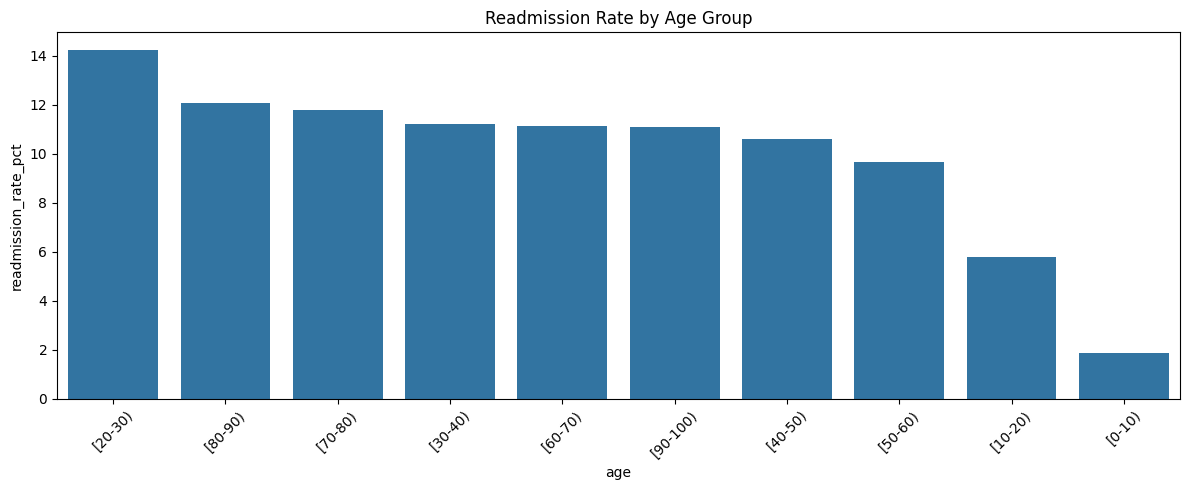

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.barplot(
    data=readmission_by_age,
    x="age",
    y="readmission_rate_pct"
)

plt.xticks(rotation=45)

plt.title(
    "Readmission Rate by Age Group"
)

plt.tight_layout()

plt.show()

In [13]:
query_gender = """
SELECT
    gender,

    COUNT(*) AS total,

    ROUND(
        100.0 *
        AVG(
            CASE
                WHEN readmitted='<30'
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS readmission_rate_pct

FROM patients

GROUP BY gender

ORDER BY readmission_rate_pct DESC
"""

readmission_by_gender = pd.read_sql(
    query_gender,
    conn
)

readmission_by_gender

,gender,total,readmission_rate_pct
0,Female,54708,11.25
1,Male,47055,11.06
2,Unknown/Invalid,3,0.00


In [14]:
readmission_by_gender.to_csv(
    OUTPUT_DIR /
    "readmission_by_gender.csv",
    index=False
)

In [15]:
query_race = """
SELECT
    race,

    COUNT(*) AS total,

    ROUND(
        100.0 *
        AVG(
            CASE
                WHEN readmitted='<30'
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS readmission_rate_pct

FROM patients

GROUP BY race

ORDER BY readmission_rate_pct DESC
"""

readmission_by_race = pd.read_sql(
    query_race,
    conn
)

readmission_by_race

,race,total,readmission_rate_pct
0,Caucasian,76099,11.29
1,AfricanAmerican,19210,11.22
2,Hispanic,2037,10.41
3,Asian,641,10.14
4,Other,1506,9.63
5,?,2273,8.27


In [16]:
readmission_by_race.to_csv(
    OUTPUT_DIR /
    "readmission_by_race.csv",
    index=False
)

In [17]:
query_stay = """
SELECT
    time_in_hospital,

    COUNT(*) AS total,

    ROUND(
        100.0 *
        AVG(
            CASE
                WHEN readmitted='<30'
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS readmission_rate_pct

FROM patients

GROUP BY time_in_hospital

ORDER BY time_in_hospital
"""

hospital_stay = pd.read_sql(
    query_stay,
    conn
)

hospital_stay.head()

,time_in_hospital,total,readmission_rate_pct
0,1,14208,8.18
1,2,17224,9.94
2,3,17756,10.67
3,4,13924,11.81
4,5,9966,12.03


In [18]:
hospital_stay.to_csv(
    OUTPUT_DIR /
    "hospital_stay_readmission.csv",
    index=False
)

In [19]:
query_meds = """
SELECT
    num_medications,

    COUNT(*) AS total,

    ROUND(
        100.0 *
        AVG(
            CASE
                WHEN readmitted='<30'
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS readmission_rate_pct

FROM patients

GROUP BY num_medications

HAVING COUNT(*) > 50

ORDER BY num_medications
"""

medication_analysis = pd.read_sql(
    query_meds,
    conn
)

medication_analysis.head()

,num_medications,total,readmission_rate_pct
0,1,262,4.20
1,2,470,8.30
2,3,900,7.22
3,4,1417,8.05
4,5,2017,7.44


In [20]:
medication_analysis.to_csv(
    OUTPUT_DIR /
    "medication_readmission.csv",
    index=False
)

In [21]:
query_diag = """
SELECT
    diag_1,

    COUNT(*) AS total,

    ROUND(
        100.0 *
        AVG(
            CASE
                WHEN readmitted='<30'
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS readmission_rate_pct

FROM patients

GROUP BY diag_1

HAVING COUNT(*) > 100

ORDER BY readmission_rate_pct DESC

LIMIT 25
"""

diagnosis_analysis = pd.read_sql(
    query_diag,
    conn
)

diagnosis_analysis

,diag_1,total,readmission_rate_pct
0,V58,228,41.67
1,443,110,21.82
2,593,101,20.79
3,572,239,20.50
4,202,104,19.23
5,250.7,871,18.94
6,790,144,18.75
7,250.6,1183,18.51
8,787,267,18.35
9,707,257,16.73


In [22]:
diagnosis_analysis.to_csv(
    OUTPUT_DIR /
    "diagnosis_readmission.csv",
    index=False
)

In [23]:
query_risk = """
SELECT
    age,
    race,

    COUNT(*) AS total,

    ROUND(
        100.0 *
        AVG(
            CASE
                WHEN readmitted='<30'
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS readmission_rate_pct

FROM patients

GROUP BY age, race

HAVING COUNT(*) > 50

ORDER BY readmission_rate_pct DESC

LIMIT 20
"""

top_risk_segments = pd.read_sql(
    query_risk,
    conn
)

top_risk_segments

,age,race,total,readmission_rate_pct
0,[20-30),Caucasian,975,16.62
1,[80-90),Hispanic,141,16.31
2,[70-80),Asian,180,15.00
3,[30-40),Other,84,13.10
4,[20-30),AfricanAmerican,540,12.59
5,[80-90),?,397,12.59
6,[70-80),Hispanic,386,12.18
7,[40-50),Hispanic,337,12.17
8,[80-90),Caucasian,14602,12.11
9,[40-50),AfricanAmerican,2787,11.95


In [24]:
top_risk_segments.to_csv(
    OUTPUT_DIR /
    "top_risk_segments.csv",
    index=False
)

In [25]:
summary_table = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique Patients",
        "Unique Encounters"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["patient_nbr"].nunique(),
        df["encounter_id"].nunique()
    ]
})

summary_table

,Metric,Value
0,Rows,101766
1,Columns,50
2,Unique Patients,71518
3,Unique Encounters,101766


In [26]:
summary_table.to_csv(
    OUTPUT_DIR /
    "dataset_summary.csv",
    index=False
)

In [27]:
conn.close()

print("Database connection closed.")

Database connection closed.
